In [ ]:
import json
import rasterio
import numpy as np 
import cv2
import tifffile
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
import glob 
import os
from concurrent.futures import ProcessPoolExecutor

MODEL 

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [4]:

from UNetPlusPlus import * 

/home/gandalf/CV_CW/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
global device
device=torch.device("cuda") if torch.cuda.is_available() else "cpu"

In [7]:
model=UNetPlusPlus(deep_supervision=True,pretrained=True)
model.to(device)

UNetPlusPlus(
  (encoder): FeatureListNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act2): ReLU(inplace=True)
        (aa): Identity()
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, ep

In [8]:
from torch.utils.data import Dataset, DataLoader
from einops import rearrange

In [9]:
from tqdm import tqdm

In [10]:
class TissueDataset(Dataset):
    def __init__(self, split="train", base_dir="/home/gandalf/CV_CW/Dataset_Splits",
                 patch_size=128, use_augmented=False):
        self.patch_size = patch_size

        image_dir = os.path.join(base_dir, split, "image")
        mask_dir  = os.path.join(base_dir, split, "masks_tissue")

        image_paths = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
        mask_paths  = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))

    
        if use_augmented and split == "train":
            aug_image_dir = os.path.join(base_dir, split, "image_augmented")
            aug_mask_dir  = os.path.join(base_dir, split, "masks_tissue_augmented")

            aug_image_paths = sorted(glob.glob(os.path.join(aug_image_dir, "*.tif")))

            for aug_img_path in aug_image_paths:
                aug_fname = os.path.basename(aug_img_path)
                
                aug_mask_path = os.path.join(aug_mask_dir, aug_fname)

                if os.path.exists(aug_mask_path):
                    image_paths.append(aug_img_path)
                    mask_paths.append(aug_mask_path)

        self.image_paths = image_paths
        self.mask_paths  = mask_paths

        self.patches_per_side  = 1024 // patch_size
        self.patches_per_image = self.patches_per_side ** 2

    def __len__(self):
        return len(self.image_paths) * self.patches_per_image

    def __getitem__(self, idx):
        img_idx   = idx // self.patches_per_image
        patch_idx = idx % self.patches_per_image

        row = patch_idx // self.patches_per_side
        col = patch_idx % self.patches_per_side
        ps  = self.patch_size
        y, x = row * ps, col * ps

        image = tifffile.imread(self.image_paths[img_idx]).astype(np.float32) / 255.0
        mask  = tifffile.imread(self.mask_paths[img_idx]).astype(np.float32) / 255.0
        image = image[:, :, :3]

        image = image[y:y+ps, x:x+ps]
        mask  = mask[y:y+ps, x:x+ps]

        image = rearrange(torch.from_numpy(image), 'h w c -> c h w')
        mask  = rearrange(torch.from_numpy(mask),  'h w c -> c h w')

        return image, mask


 

In [ ]:
from torch.utils.data import WeightedRandomSampler

def compute_patch_weights(dataset, boost=5.0):
    weights = []
    num_images = len(dataset.image_paths)
    ps = dataset.patch_size
    pps = dataset.patches_per_side

    print("Computing per-patch weights...")
    for img_idx in tqdm(range(num_images)):
        mask = tifffile.imread(dataset.mask_paths[img_idx]).astype(np.float32)
        for row in range(pps):
            for col in range(pps):
                y, x = row * ps, col * ps
                patch_mask = mask[y:y+ps, x:x+ps]
                minority_frac = (patch_mask[:, :, 1].sum() + patch_mask[:, :, 2].sum()) / (ps * ps * 255.0)
                weight = 1.0 + boost * minority_frac
                weights.append(weight)

    return weights



train_dataset = TissueDataset(split="train", use_augmented=False)
val_dataset   = TissueDataset(split="validation", use_augmented=False)
test_dataset  = TissueDataset(split="test", use_augmented=False)

train_weights = compute_patch_weights(train_dataset, boost=5.0)
train_sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)


train_loader = DataLoader(train_dataset, batch_size=4, sampler=train_sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,        num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False,        num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} patches (weighted sampling, boost=5.0)")
print(f"Val:   {len(val_dataset)} patches (uniform)")
print(f"Test:  {len(test_dataset)} patches (uniform)")


Computing per-patch weights...


100%|██████████| 163/163 [00:01<00:00, 122.12it/s]

Train: 10432 patches (weighted sampling, boost=5.0)
Val:   1280 patches (uniform)
Test:  1408 patches (uniform)


In [ ]:
class DiceLoss(nn.Module):

    def __init__(self, alpha=0.7, beta=0.3, smooth=1e-6):
        super().__init__()
        self.alpha  = alpha   
        self.beta   = beta   
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = F.softmax(preds, dim=1)
        TP = (preds * targets).sum(dim=(2, 3))
        FP = (preds * (1 - targets)).sum(dim=(2, 3))
        FN = ((1 - preds) * targets).sum(dim=(2, 3))
        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return 1.0 - tversky.mean()


In [ ]:
class UnifiedFocalLoss(nn.Module):
   
    def __init__(self, weight=None, delta=0.7, gamma=0.5, lambd=0.5, epsilon=1e-7):
        super(UnifiedFocalLoss, self).__init__()
        self.delta = delta       
        self.gamma = gamma      
        self.lambd = lambd       
        self.epsilon = epsilon
        self.weight = weight  

    def forward(self, preds, targets_onehot):
        probs = F.softmax(preds, dim=1)

        ce_loss     = -targets_onehot       * torch.log(probs            + self.epsilon)
        bg_ce_loss  = -(1-targets_onehot)   * torch.log(1 - probs        + self.epsilon)
        focal_weight    = torch.pow(1 - probs, self.gamma)
        bg_focal_weight = torch.pow(probs,     self.gamma)

        afl = (self.delta * focal_weight * ce_loss +
            (1 - self.delta) * bg_focal_weight * bg_ce_loss)
        afl = afl.mean()

        tp = torch.sum(probs * targets_onehot,        dim=(0, 2, 3))
        fp = torch.sum(probs * (1 - targets_onehot),  dim=(0, 2, 3))
        fn = torch.sum((1 - probs) * targets_onehot,  dim=(0, 2, 3))

        tversky_index = (tp + self.epsilon) / (
            tp + self.delta * fn + (1 - self.delta) * fp + self.epsilon
        )
        aftl = torch.pow((1 - tversky_index).clamp(min=0.0), 1 - self.gamma)
        aftl = aftl.mean()

        return self.lambd * afl + (1 - self.lambd) * aftl

class CombinedLoss(nn.Module):
    
    def __init__(self, weights=None, lambd=0.5, delta=0.7, gamma=0.5):
        super().__init__()
        self.ufl = UnifiedFocalLoss(weight=weights, delta=delta, gamma=gamma, lambd=lambd)

    def forward(self, preds, targets_onehot):
        
        return self.ufl(preds, targets_onehot)

In [ ]:
def rgb_mask_to_onehot(mask_rgb):
  
    class_idx = torch.argmax(mask_rgb, dim=1)        
    bg = mask_rgb.sum(dim=1) == 0                     


    class_idx[bg] = 0    

    onehot = F.one_hot(class_idx, num_classes=3)      # (B, H, W, C)
    onehot = rearrange(onehot, 'b h w c -> b c h w').float()

    bg_mask = bg.unsqueeze(1)           # (B, 1, H, W)
    onehot[bg_mask.expand_as(onehot)] = 0.0

    return onehot


In [31]:
from tqdm import tqdm
import time

In [ ]:
def train(model, train_loader, val_loader, device,
          num_epochs=15, lr=1e-3, weight=None):
    #ds_weights=[0.1,0.2,0.3,0.4]
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )
    criterion = CombinedLoss(weights=weight)

    best_val_loss = float("inf")
    train_losses = []
    val_losses = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        t0 = time.time()

        for batch_idx, (images, masks) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]")):
            images = images.to(device)
            targets = rgb_mask_to_onehot(masks).to(device)

            preds = model(images)

            if isinstance(preds, list):
                loss = sum(criterion(p, targets) for p in preds) / len(preds)
            else:
                loss = criterion(preds, targets)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

           
            scheduler.step(epoch - 1 + batch_idx / len(train_loader))

            train_loss += loss.item()

        train_loss /= len(train_loader)
        epoch_time = time.time() - t0

        # ── Validation ──
        model.eval()
        val_loss = 0.0
        dice_scores = torch.zeros(3, device=device)

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Val]"):
                images = images.to(device)
                targets = rgb_mask_to_onehot(masks).to(device)

                preds = model(images)

                if isinstance(preds, list):
                    loss = sum(criterion(p, targets) for p in preds) / len(preds)
                    preds = preds[-1]
                else:
                    loss = criterion(preds, targets)

                val_loss += loss.item()
                
        val_loss /= len(val_loader)


        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        
              f"LR: {current_lr:.2e} | {epoch_time:.1f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print(f" New best model saved (val_loss={val_loss:.4f})")

    print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
    plt.plot(range(1, num_epochs + 1), val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return train_losses, val_losses


In [46]:
t,v=train(model, train_loader, val_loader, device,
      num_epochs=10, lr=1e-4,weight=None)

Epoch 1/10 [Val]: 100%|██████████| 320/320 [00:15<00:00, 21.15it/s]


Epoch 1/10 | Train Loss: 0.4810 | Val Loss: 0.4997 | LR: 9.76e-05 | 366.9s
   New best model saved (val_loss=0.4997)


Epoch 2/10 [Val]: 100%|██████████| 320/320 [00:25<00:00, 12.35it/s]


Epoch 2/10 | Train Loss: 0.4476 | Val Loss: 0.5091 | LR: 9.05e-05 | 380.7s


Epoch 3/10 [Val]: 100%|██████████| 320/320 [00:22<00:00, 14.11it/s]


...

Epoch 6/10 | Train Loss: 0.3808 | Val Loss: 0.4780 | LR: 3.52e-05 | 385.0s
   New best model saved (val_loss=0.4780)


Epoch 7/10 [Val]: 100%|██████████| 320/320 [00:21<00:00, 14.73it/s]


Epoch 7/10 | Train Loss: 0.3698 | Val Loss: 0.4853 | LR: 2.14e-05 | 396.8s


Epoch 8/10 [Train]:  37%|███▋      | 962/2608 [02:36<04:27,  6.16it/s]


KeyboardInterrupt: 

In [12]:
torch.cuda.empty_cache()

In [13]:
model.load_state_dict(torch.load('best_model_nonpretrained_se_resnet.pth'))

<All keys matched successfully>

In [14]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)

101090812


In [64]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np


In [ ]:
def evaluate_metrics(model, dataloader, device, num_classes=3):

    conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating"):
            images  = images.to(device)
            targets = rgb_mask_to_onehot(masks).to(device)   

            preds = model(images)
            if isinstance(preds, list):
                preds = preds[-1]

            pred_cls   = preds.argmax(dim=1).flatten()
            target_cls = targets.argmax(dim=1).flatten()     

           
            valid = targets.sum(dim=1).flatten() > 0         
            pred_cls   = pred_cls[valid]
            target_cls = target_cls[valid]

            
            for t, p in zip(target_cls, pred_cls):
                conf_matrix[t, p] += 1


    TP = conf_matrix.diag().float()                             
    FP = conf_matrix.sum(dim=0).float() - TP                     
    FN = conf_matrix.sum(dim=1).float() - TP                 

    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    iou       = TP / (TP + FP + FN + 1e-8)
    dice      = 2 * TP / (2 * TP + FP + FN + 1e-8)

    pixel_acc = TP.sum() / conf_matrix.sum().float()            


    class_names = ["Tumor", "Stroma", "Other"]
    print(f"\n{'Class':<10} {'IoU':>8} {'Dice':>8} {'Prec':>8} {'Recall':>8}")
    print("─" * 44)
    for c in range(num_classes):
        print(f"{class_names[c]:<10} {iou[c]:>8.4f} {dice[c]:>8.4f} "
              f"{precision[c]:>8.4f} {recall[c]:>8.4f}")
    print("─" * 44)
    print(f"{'Mean':<10} {iou.mean():>8.4f} {dice.mean():>8.4f} "
          f"{precision.mean():>8.4f} {recall.mean():>8.4f}")
    print(f"\nPixel Accuracy: {pixel_acc:.4f}")

    return {
        "iou": iou.cpu(), "dice": dice.cpu(),
        "precision": precision.cpu(), "recall": recall.cpu(),
        "pixel_accuracy": pixel_acc.cpu(),
        "confusion_matrix": conf_matrix.cpu(),
    }


In [ ]:

results = evaluate_metrics(model, test_loader, device)

Evaluating: 100%|██████████| 352/352 [15:34<00:00,  2.65s/it]


Class           IoU     Dice     Prec   Recall
────────────────────────────────────────────
Tumor        0.7417   0.8517   0.8800   0.8252
Stroma       0.3705   0.5407   0.4904   0.6025
Other        0.2909   0.4507   0.4341   0.4686
────────────────────────────────────────────
Mean         0.4677   0.6144   0.6015   0.6321

Pixel Accuracy: 0.7645


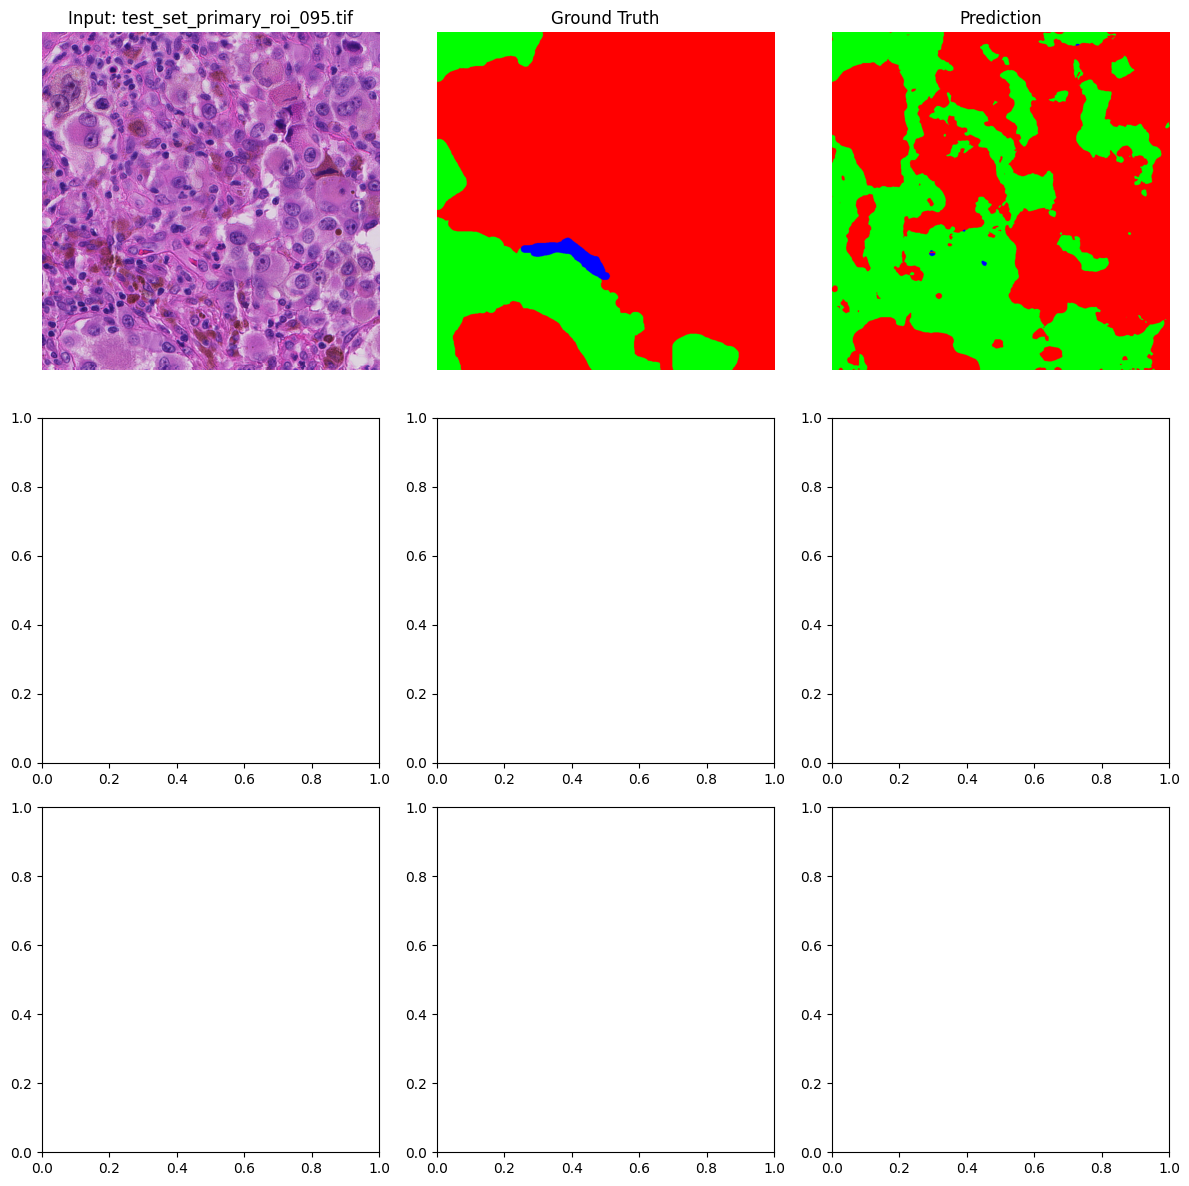

In [ ]:
CLASS_COLORS = np.array([
    [255, 0, 0],    # 0: tumor
    [0, 255, 0],    # 1: stroma
    [0, 0, 255],    # 2: other
], dtype=np.uint8)

def class_idx_to_rgb(class_map):
    h, w = class_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, color in enumerate(CLASS_COLORS):
        rgb[class_map == cls_id] = color
    return rgb

base_dir = "/home/gandalf/CV_CW/Dataset_Splits"
image_dir = os.path.join(base_dir, "test", "image")
mask_dir  = os.path.join(base_dir, "test", "masks_tissue")

all_image_paths = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
all_mask_paths  = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))

indices = list(range(len(all_image_paths)))
random.shuffle(indices)
selected_indices = indices[:1]

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

num_examples = 3
fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4 * num_examples))
if num_examples == 1:
    axes = axes[np.newaxis, :]  

with torch.no_grad():
    for images_shown, idx in enumerate(selected_indices):
        
        img_path = all_image_paths[idx]
        mask_path = all_mask_paths[idx]
        img_name = os.path.basename(img_path)

        image_np = tifffile.imread(img_path).astype(np.float32) / 255.0
        mask_np  = tifffile.imread(mask_path).astype(np.float32) / 255.0
        
        image_np = image_np[:, :, :3] 


        image_tensor = rearrange(torch.from_numpy(image_np), 'h w c -> c h w').unsqueeze(0).to(device)
        mask_tensor  = rearrange(torch.from_numpy(mask_np),  'h w c -> c h w').unsqueeze(0).to(device)

        targets = rgb_mask_to_onehot(mask_tensor).to(device)

        preds = model(image_tensor)
        if isinstance(preds, list):
            preds = preds[-1]


        pred_classes = preds.argmax(dim=1).squeeze(0).cpu().numpy()        # (H, W)
        target_classes = targets.argmax(dim=1).squeeze(0).cpu().numpy()    # (H, W)
        fg_mask = targets.sum(dim=1).squeeze(0).cpu().numpy() > 0          # (H, W)

        img_viz = (image_np * 255).clip(0, 255).astype(np.uint8)

      
        gt_map = target_classes.copy()
        gt_map[~fg_mask] = -1
        gt_rgb = class_idx_to_rgb(gt_map)

        
        pred_rgb = class_idx_to_rgb(pred_classes)
        axes[images_shown, 0].imshow(img_viz)
        axes[images_shown, 0].set_title(f"Input: {img_name}")
        axes[images_shown, 0].axis("off")

        axes[images_shown, 1].imshow(gt_rgb)
        axes[images_shown, 1].set_title("Ground Truth")
        axes[images_shown, 1].axis("off")

        axes[images_shown, 2].imshow(pred_rgb)
        axes[images_shown, 2].set_title("Prediction")
        axes[images_shown, 2].axis("off")

plt.tight_layout()
plt.show()
